In [1]:
import torch

# STEP 1: Set the Financial Parameters
# These are the static rules of our specific market simulation
r = 0.05       # Risk-free interest rate (5%)
K = 1.0        # Strike Price of the option
T = 1.0        # Time to expiration (1 year)

# Set the limits of our mathematical "sandbox"
S_min = 0.0
S_max = 3.0    # Cap the stock price high enough to cover realistic scenarios
t_min = 0.0
t_max = T

# NEW: Set the limits for our dynamic Volatility (sigma)
sigma_min = 0.05 # Low volatility (5%)
sigma_max = 0.80 # High volatility (80%)

# Number of data points to generate
N_interior = 10000  # Points inside the grid (where the PDE must equal 0)
N_boundary = 2000   # Points at the edges (where we know the exact answer)

# ==========================================
# STEP 2: Sample the Interior (Collocation Points)
# ==========================================
# Generate random (Stock Price, Time, Volatility) combinations.
S_interior = torch.empty(N_interior, 1).uniform_(S_min, S_max)
t_interior = torch.empty(N_interior, 1).uniform_(t_min, t_max)
sigma_interior = torch.empty(N_interior, 1).uniform_(sigma_min, sigma_max) # NEW INPUT

# CRITICAL PINN STEP: Tell PyTorch to track operations on these tensors for Autograd.
S_interior.requires_grad = True
t_interior.requires_grad = True

# ==========================================
# STEP 3: Sample the Boundaries (NO NOISE)
# ==========================================
# IMPORTANT: Every boundary condition must now also include a random sigma tensor!

# A) Terminal Condition (The moment the contract expires: t = T)
S_terminal = torch.empty(N_boundary, 1).uniform_(S_min, S_max)
t_terminal = torch.full((N_boundary, 1), T)
sigma_terminal = torch.empty(N_boundary, 1).uniform_(sigma_min, sigma_max) # NEW

# Calculate the exact mathematical payoff.
V_terminal_exact = torch.clamp(S_terminal - K, min=0.0)
V_terminal = V_terminal_exact


# B) Lower Boundary Condition (If the stock goes bankrupt: S = 0)
S_zero = torch.zeros(N_boundary, 1)
t_zero = torch.empty(N_boundary, 1).uniform_(t_min, t_max)
sigma_zero = torch.empty(N_boundary, 1).uniform_(sigma_min, sigma_max) # NEW

# If the stock is worth 0, the option is worthless.
V_zero = torch.zeros(N_boundary, 1)


# C) Upper Boundary Condition (S = S_max)
S_upper = torch.full((N_boundary, 1), S_max)
t_upper = torch.empty(N_boundary, 1).uniform_(t_min, t_max)
sigma_upper = torch.empty(N_boundary, 1).uniform_(sigma_min, sigma_max) # NEW

# The mathematical limit of a European Call option as S gets very large: V ≈ S - K * e^(-r(T-t))
V_upper = S_upper - K * torch.exp(-r * (T - t_upper))

In [2]:
import torch
import torch.nn as nn

# ==========================================
# STEP 4: Define the Neural Network Architecture
# ==========================================

class BlackScholesPINN(nn.Module):
    def __init__(self, hidden_layers=4, neurons_per_layer=50):
        super(BlackScholesPINN, self).__init__()
        layers = []

        # 1. INPUT LAYER
        # UPGRADE: Now takes 3 inputs: Stock Price (S), Time (t), and Volatility (sigma)
        layers.append(nn.Linear(3, neurons_per_layer))
        layers.append(nn.Tanh())

        # 2. HIDDEN LAYERS
        for _ in range(hidden_layers):
            layers.append(nn.Linear(neurons_per_layer, neurons_per_layer))
            layers.append(nn.Tanh())

        # 3. OUTPUT LAYER
        layers.append(nn.Linear(neurons_per_layer, 1))

        self.network = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.network.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0.0)

    # UPGRADE: Added sigma as a required input parameter
    def forward(self, S, t, sigma):
        # Concatenate the 3 column vectors into one matrix of shape (Batch_Size, 3)
        inputs = torch.cat([S, t, sigma], dim=1)
        V_pred = self.network(inputs)
        return V_pred

# Initialize our upgraded model
model = BlackScholesPINN(hidden_layers=4, neurons_per_layer=50)
print(model)

BlackScholesPINN(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=50, bias=True)
    (1): Tanh()
    (2): Linear(in_features=50, out_features=50, bias=True)
    (3): Tanh()
    (4): Linear(in_features=50, out_features=50, bias=True)
    (5): Tanh()
    (6): Linear(in_features=50, out_features=50, bias=True)
    (7): Tanh()
    (8): Linear(in_features=50, out_features=50, bias=True)
    (9): Tanh()
    (10): Linear(in_features=50, out_features=1, bias=True)
  )
)


In [3]:
def calculate_loss(model, S_interior, t_interior, sigma_interior, S_terminal, t_terminal, sigma_terminal, V_terminal, S_zero, t_zero, sigma_zero, V_zero, S_upper, t_upper, sigma_upper, V_upper, r):

    mse_loss = nn.MSELoss()

    # ==========================================
    # 1. BOUNDARY LOSS (The Reality Check)
    # ==========================================

    # UPGRADE: Pass the respective sigma tensors into the model for every boundary
    V_pred_terminal = model(S_terminal, t_terminal, sigma_terminal)
    loss_terminal = mse_loss(V_pred_terminal, V_terminal)

    V_pred_zero = model(S_zero, t_zero, sigma_zero)
    loss_zero = mse_loss(V_pred_zero, V_zero)

    V_pred_upper = model(S_upper, t_upper, sigma_upper)
    loss_upper = mse_loss(V_pred_upper, V_upper)

    loss_boundary = loss_terminal + loss_zero + loss_upper


    # ==========================================
    # 2. PDE LOSS (The Physics Check via Autograd)
    # ==========================================

    # UPGRADE: Pass the interior sigma tensor
    V_pred_interior = model(S_interior, t_interior, sigma_interior)

    # --- FIRST DERIVATIVES ---
    V_t = torch.autograd.grad(
        V_pred_interior, t_interior,
        grad_outputs=torch.ones_like(V_pred_interior),
        retain_graph=True,
        create_graph=True
    )[0]

    V_S = torch.autograd.grad(
        V_pred_interior, S_interior,
        grad_outputs=torch.ones_like(V_pred_interior),
        retain_graph=True,
        create_graph=True
    )[0]

    # --- SECOND DERIVATIVE ---
    V_SS = torch.autograd.grad(
        V_S, S_interior,
        grad_outputs=torch.ones_like(V_S),
        retain_graph=True,
        create_graph=True
    )[0]

    # --- THE BLACK-SCHOLES EQUATION ---
    # UPGRADE: sigma_interior is now a tensor being squared, instead of a static float
    residual = V_t + 0.5 * (sigma_interior**2) * (S_interior**2) * V_SS + r * S_interior * V_S - r * V_pred_interior

    target_zeros = torch.zeros_like(residual)
    loss_pde = mse_loss(residual, target_zeros)

    # ==========================================
    # 3. TOTAL LOSS
    # ==========================================
    total_loss = loss_pde + loss_boundary

    return total_loss, loss_boundary, loss_pde

In [4]:
import torch.optim as optim

# ==========================================
# STAGE 1: The Adam Optimizer
# ==========================================
optimizer_adam = optim.Adam(model.parameters(), lr=0.001)
epochs_adam = 2500

print("Starting Stage 1: Adam Optimization")
for epoch in range(epochs_adam):
    optimizer_adam.zero_grad()

    # UPGRADE: Added the 4 sigma tensors to the arguments
    total_loss, loss_boundary, loss_pde = calculate_loss(
        model,
        S_interior, t_interior, sigma_interior,
        S_terminal, t_terminal, sigma_terminal, V_terminal,
        S_zero, t_zero, sigma_zero, V_zero,
        S_upper, t_upper, sigma_upper, V_upper,
        r
    )

    total_loss.backward()
    optimizer_adam.step()

    if epoch % 1000 == 0:
        print(f"Adam Epoch {epoch:04d} | Total Loss: {total_loss.item():.6f} | PDE Loss: {loss_pde.item():.6f}")
print("Adam Optimization Complete.\n")

# ==========================================
# STAGE 2: The L-BFGS Optimizer
# ==========================================
optimizer_lbfgs = optim.LBFGS(model.parameters(), lr=0.1, max_iter=500, tolerance_grad=1e-7, tolerance_change=1e-9, history_size=50)

print("Starting Stage 2: L-BFGS Optimization")
lbfgs_iter = 0

def closure():
    global lbfgs_iter
    optimizer_lbfgs.zero_grad()

    # UPGRADE: Added the 4 sigma tensors to the arguments here too
    total_loss, loss_boundary, loss_pde = calculate_loss(
        model,
        S_interior, t_interior, sigma_interior,
        S_terminal, t_terminal, sigma_terminal, V_terminal,
        S_zero, t_zero, sigma_zero, V_zero,
        S_upper, t_upper, sigma_upper, V_upper,
        r
    )

    total_loss.backward()

    lbfgs_iter += 1
    if lbfgs_iter % 100 == 0:
        print(f"L-BFGS Iter {lbfgs_iter:04d} | Total Loss: {total_loss.item():.6f} | PDE Loss: {loss_pde.item():.6f}")

    return total_loss

optimizer_lbfgs.step(closure)
print("L-BFGS Optimization Complete.")

Starting Stage 1: Adam Optimization
Adam Epoch 0000 | Total Loss: 9.399906 | PDE Loss: 0.003487
Adam Epoch 1000 | Total Loss: 0.002064 | PDE Loss: 0.000474
Adam Epoch 2000 | Total Loss: 0.001483 | PDE Loss: 0.000384
Adam Optimization Complete.

Starting Stage 2: L-BFGS Optimization
L-BFGS Iter 0100 | Total Loss: 0.001039 | PDE Loss: 0.000387
L-BFGS Iter 0200 | Total Loss: 0.000762 | PDE Loss: 0.000281
L-BFGS Iter 0300 | Total Loss: 0.000654 | PDE Loss: 0.000293
L-BFGS Iter 0400 | Total Loss: 0.000571 | PDE Loss: 0.000248
L-BFGS Iter 0500 | Total Loss: 0.000486 | PDE Loss: 0.000195
L-BFGS Optimization Complete.


In [5]:
# The Exact Black-Scholes Formula for a European Call
def exact_black_scholes(S, t, K, r, sigma, T):
    # Avoid division by zero at exactly expiration
    tau = T - t
    tau = np.maximum(tau, 1e-10)

    # FIX: Avoid log(0) by making S slightly greater than 0 just for the d1 calculation
    S_safe = np.maximum(S, 1e-10)

    d1 = (np.log(S_safe / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)

    # Calculate exact call price
    call_price = S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)

    # If S was actually 0, force the price to be exactly 0.
    call_price = np.where(S == 0, 0.0, call_price)

    # At exact expiration, payoff is strictly max(S-K, 0)
    payoff = np.maximum(S - K, 0)
    return np.where(t == T, payoff, call_price)

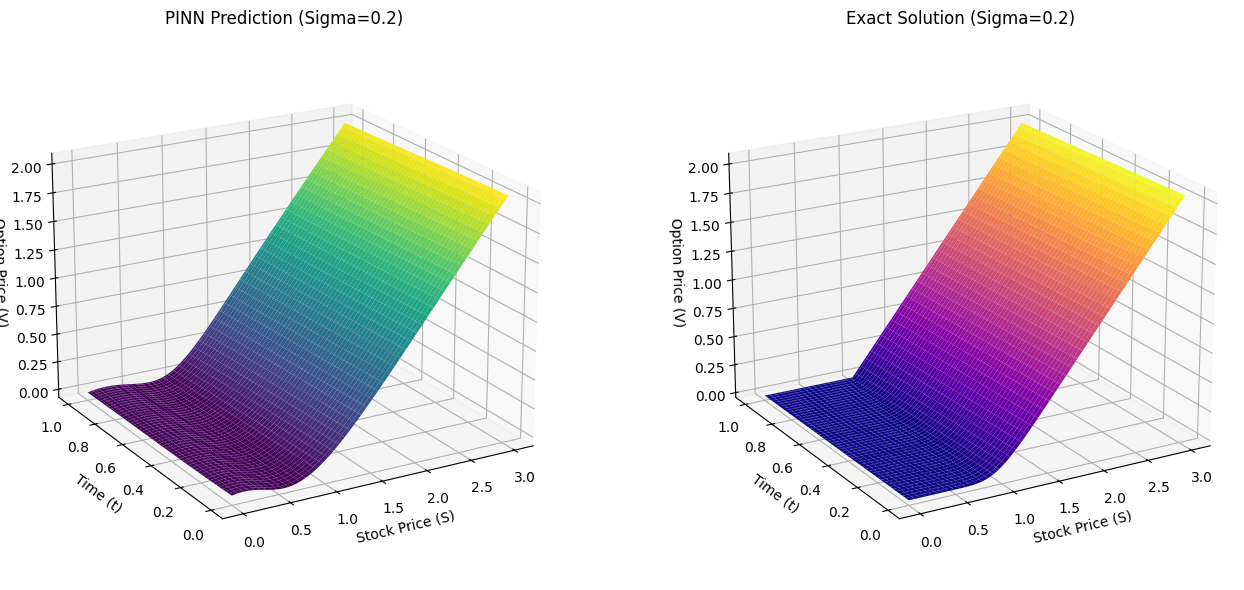

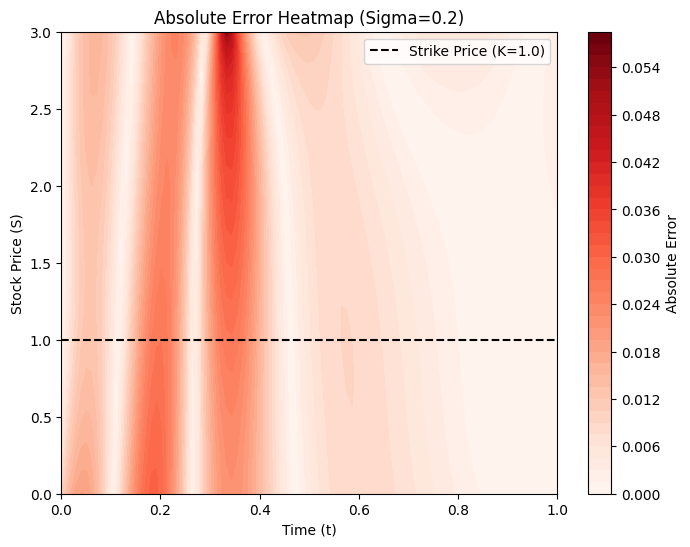

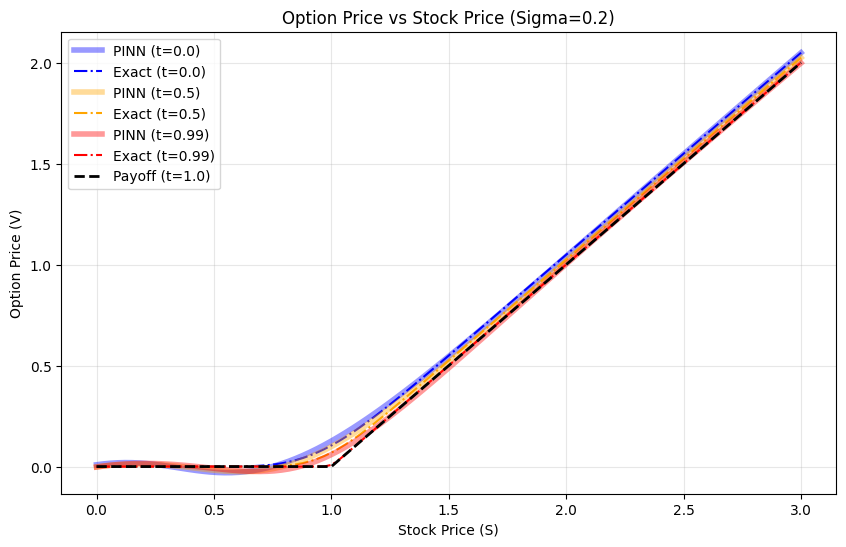

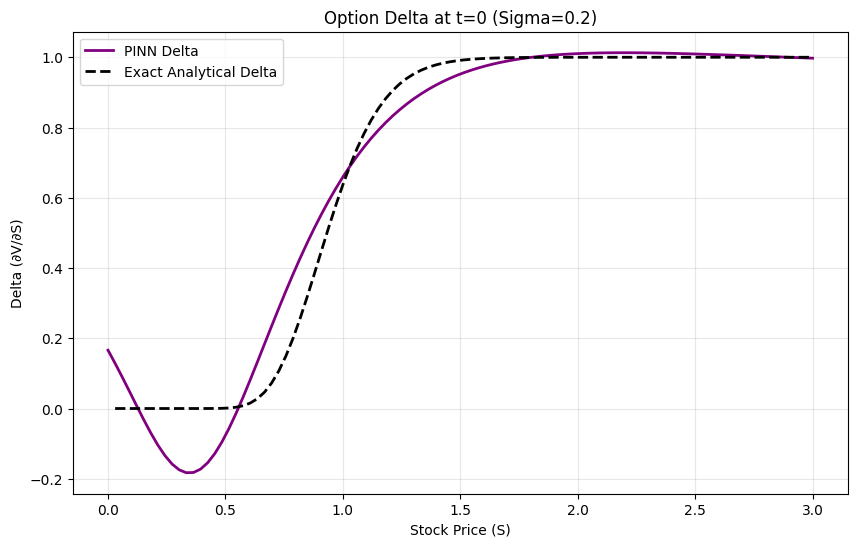

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# UPGRADE: Choose a specific volatility to plot!
# You can change this to 0.4 or 0.8 later to instantly see how the curves change!
sigma_eval = 0.2

S_plot = np.linspace(0, 3.0, 100)
t_plot = np.linspace(0, T, 100)
S_mesh, t_mesh = np.meshgrid(S_plot, t_plot)

S_flat = torch.tensor(S_mesh.flatten(), dtype=torch.float32).unsqueeze(1)
t_flat = torch.tensor(t_mesh.flatten(), dtype=torch.float32).unsqueeze(1)
# UPGRADE: Create a flat tensor of just our evaluation volatility
sigma_flat = torch.full_like(S_flat, sigma_eval)

model.eval()
with torch.no_grad():
    # Pass all 3 inputs
    V_pred_flat = model(S_flat, t_flat, sigma_flat).numpy()
V_pred_mesh = V_pred_flat.reshape(S_mesh.shape)

# Pass the specific eval volatility to the exact formula
V_exact_mesh = exact_black_scholes(S_mesh, t_mesh, K, r, sigma_eval, T)

# --- 3D PLOTTING (Code remains the same) ---
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(S_mesh, t_mesh, V_pred_mesh, cmap='viridis', edgecolor='none')
ax1.set_title(f'PINN Prediction (Sigma={sigma_eval})')
ax1.set_xlabel('Stock Price (S)')
ax1.set_ylabel('Time (t)')
ax1.set_zlabel('Option Price (V)')
ax1.view_init(elev=20, azim=-120)

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(S_mesh, t_mesh, V_exact_mesh, cmap='plasma', edgecolor='none')
ax2.set_title(f'Exact Solution (Sigma={sigma_eval})')
ax2.set_xlabel('Stock Price (S)')
ax2.set_ylabel('Time (t)')
ax2.set_zlabel('Option Price (V)')
ax2.view_init(elev=20, azim=-120)

plt.tight_layout()
plt.show()

# --- ERROR HEATMAP ---
absolute_error = np.abs(V_pred_mesh - V_exact_mesh)
plt.figure(figsize=(8, 6))
contour = plt.contourf(t_mesh, S_mesh, absolute_error.T, levels=50, cmap='Reds')
plt.colorbar(contour, label='Absolute Error')
plt.title(f'Absolute Error Heatmap (Sigma={sigma_eval})')
plt.xlabel('Time (t)')
plt.ylabel('Stock Price (S)')
plt.axhline(y=K, color='black', linestyle='--', label=f'Strike Price (K={K})')
plt.legend()
plt.show()

# --- 2D TIME SLICES ---
plt.figure(figsize=(10, 6))
time_slices = [0.0, 0.5, 0.99]
colors = ['blue', 'orange', 'red']

for i, t_val in enumerate(time_slices):
    S_slice = torch.tensor(S_plot, dtype=torch.float32).unsqueeze(1)
    t_slice = torch.full((len(S_plot), 1), t_val, dtype=torch.float32)
    # UPGRADE: Add sigma slice
    sigma_slice = torch.full((len(S_plot), 1), sigma_eval, dtype=torch.float32)

    with torch.no_grad():
        V_slice_pred = model(S_slice, t_slice, sigma_slice).numpy().flatten()

    V_slice_exact = exact_black_scholes(S_plot, t_val, K, r, sigma_eval, T)

    plt.plot(S_plot, V_slice_pred, color=colors[i], linestyle='-', linewidth=4, alpha=0.4, label=f'PINN (t={t_val})')
    plt.plot(S_plot, V_slice_exact, color=colors[i], linestyle='dashdot', linewidth=1.5, alpha=1.0, label=f'Exact (t={t_val})')

payoff = np.maximum(S_plot - K, 0)
plt.plot(S_plot, payoff, color='black', linestyle='--', linewidth=2, label='Payoff (t=1.0)')
plt.title(f'Option Price vs Stock Price (Sigma={sigma_eval})')
plt.xlabel('Stock Price (S)')
plt.ylabel('Option Price (V)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- DELTA CALCULATION ---
S_tensor = torch.tensor(S_plot, dtype=torch.float32).unsqueeze(1)
S_tensor.requires_grad = True
t_tensor = torch.zeros((len(S_plot), 1), dtype=torch.float32)
# UPGRADE: Add sigma tensor for Delta
sigma_tensor = torch.full((len(S_plot), 1), sigma_eval, dtype=torch.float32)

# Pass all 3
V_tensor = model(S_tensor, t_tensor, sigma_tensor)

Delta_PINN = torch.autograd.grad(
    V_tensor, S_tensor,
    grad_outputs=torch.ones_like(V_tensor),
    create_graph=False
)[0].detach().numpy().flatten()

d1 = (np.log(S_plot[1:] / K) + (r + 0.5 * sigma_eval**2) * T) / (sigma_eval * np.sqrt(T))
Delta_exact = norm.cdf(d1)

plt.figure(figsize=(10, 6))
plt.plot(S_plot, Delta_PINN, label='PINN Delta', color='purple', linewidth=2)
plt.plot(S_plot[1:], Delta_exact, label='Exact Analytical Delta', color='black', linestyle='--', linewidth=2)
plt.title(f'Option Delta at t=0 (Sigma={sigma_eval})')
plt.xlabel('Stock Price (S)')
plt.ylabel('Delta (∂V/∂S)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

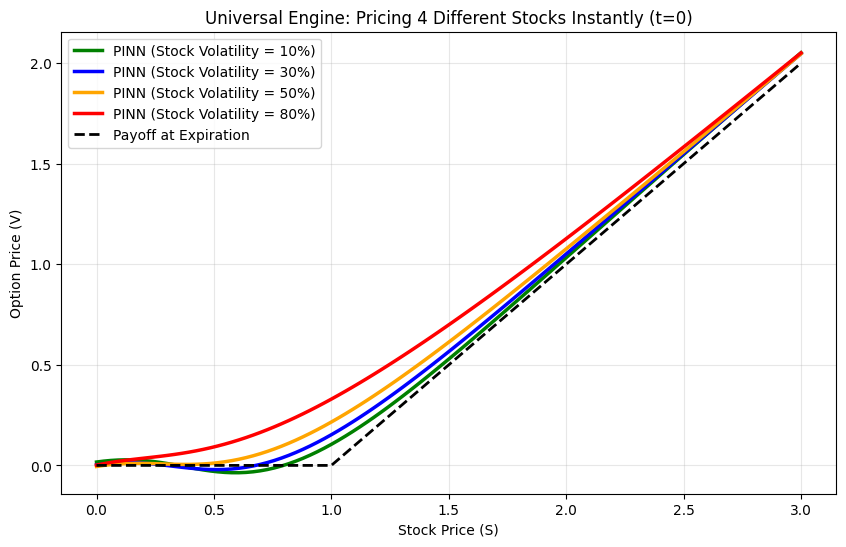

In [7]:
plt.figure(figsize=(10, 6))

# Let's test 4 different stocks ranging from very safe to highly volatile
sigmas_to_test = [0.1, 0.3, 0.5, 0.8]
colors = ['green', 'blue', 'orange', 'red']

# We are looking at prices for today (t=0)
t_val = 0.0
S_slice = torch.tensor(S_plot, dtype=torch.float32).unsqueeze(1)
t_slice = torch.full((len(S_plot), 1), t_val, dtype=torch.float32)

for i, sig in enumerate(sigmas_to_test):
    # Create a tensor for this specific stock's volatility
    sigma_slice = torch.full((len(S_plot), 1), sig, dtype=torch.float32)

    # Ask the PINN to price this specific stock
    with torch.no_grad():
        V_slice_pred = model(S_slice, t_slice, sigma_slice).numpy().flatten()

    # Plot the line
    plt.plot(S_plot, V_slice_pred, color=colors[i], linewidth=2.5, label=f'PINN (Stock Volatility = {int(sig*100)}%)')

# Add the baseline payoff contract for reference
payoff = np.maximum(S_plot - K, 0)
plt.plot(S_plot, payoff, color='black', linestyle='--', linewidth=2, label='Payoff at Expiration')

plt.title('Universal Engine: Pricing 4 Different Stocks Instantly (t=0)')
plt.xlabel('Stock Price (S)')
plt.ylabel('Option Price (V)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()l